In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df=pd.read_csv("college_student_placement_dataset.csv")
print(df.head())
print("Data Loaded Successfully!\n")

  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1       

In [40]:
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

First 5 rows:
  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3             

In [41]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


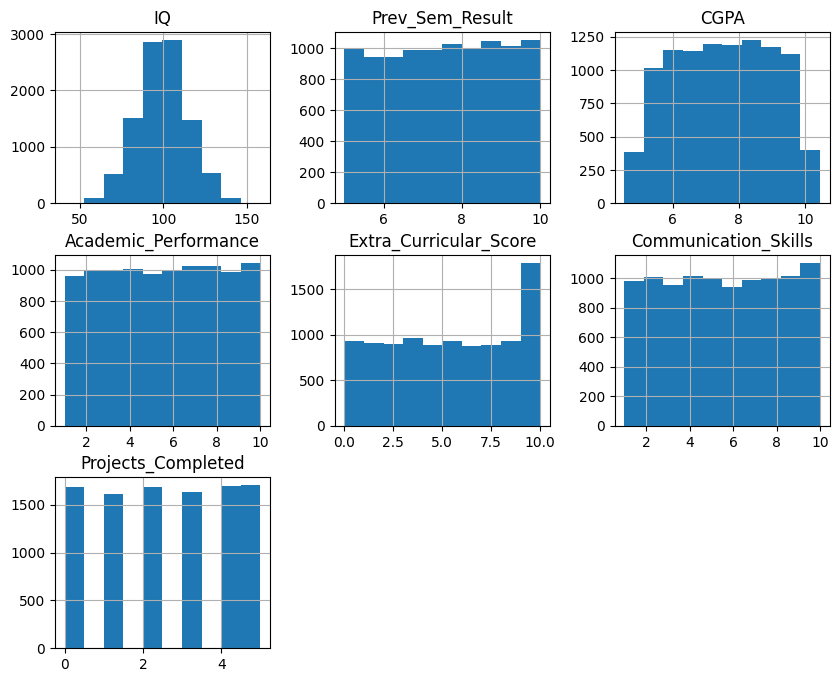

In [42]:
df.hist(figsize=(10,8))
plt.show()

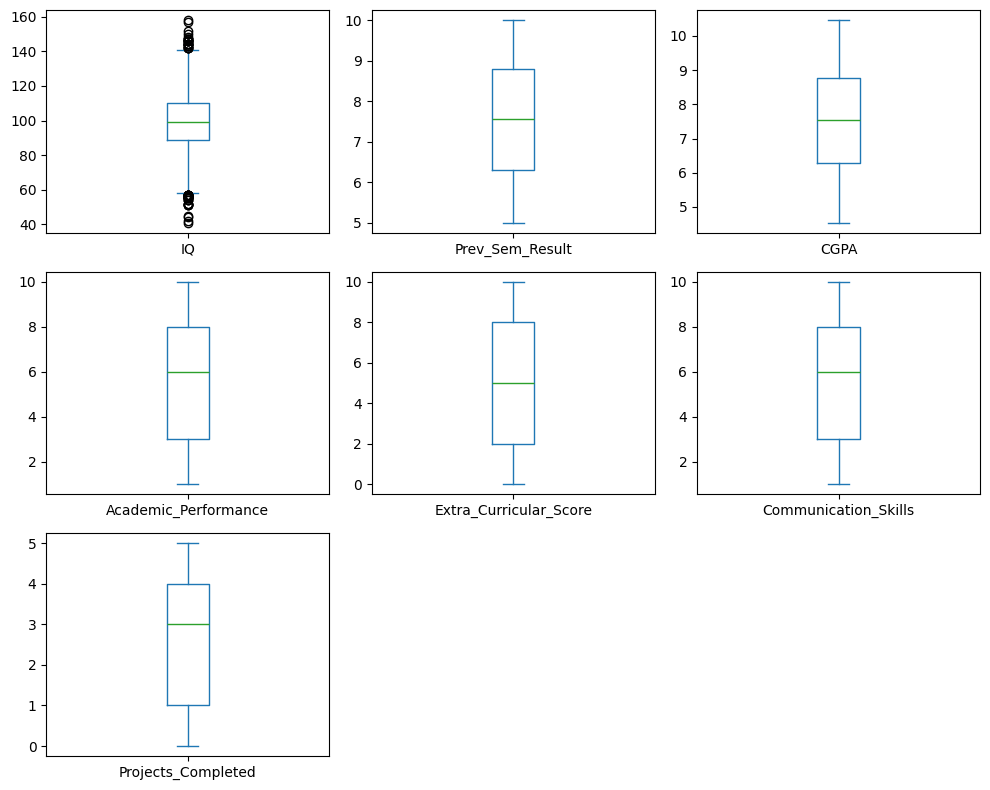

In [43]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.plot(kind='box', subplots=True, layout=(3,3), figsize=(10,8))
plt.tight_layout()
plt.show()

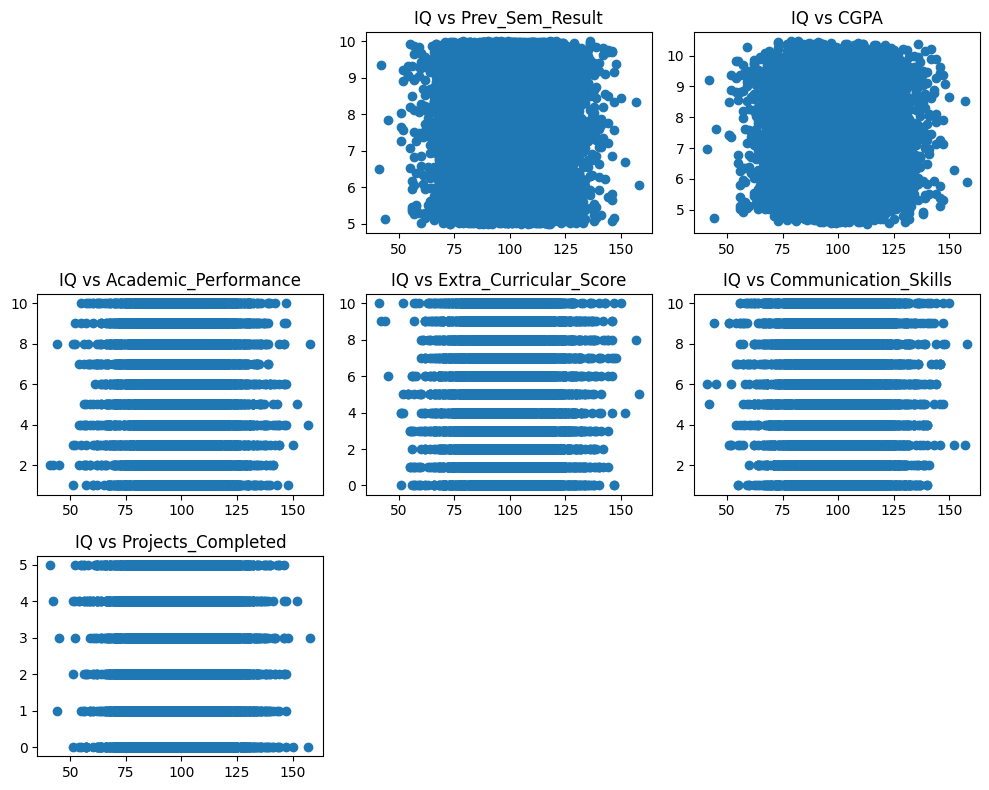

In [44]:
numeric_cols = df.select_dtypes(include='number')
cols = numeric_cols.columns
plt.figure(figsize=(10,8))
for i, col in enumerate(cols):
    if col != cols[0]:  
        plt.subplot(3,3,i+1)
        plt.scatter(df[cols[0]], df[col])
        plt.title(f"{cols[0]} vs {col}")
plt.tight_layout()
plt.show()

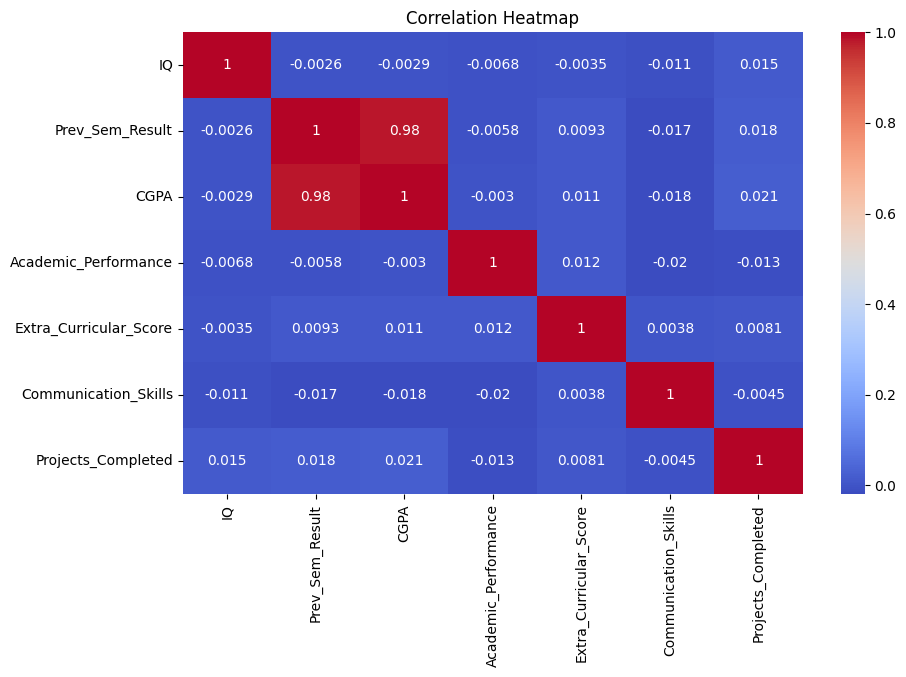

In [45]:
numeric=df.select_dtypes(include='number')
plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

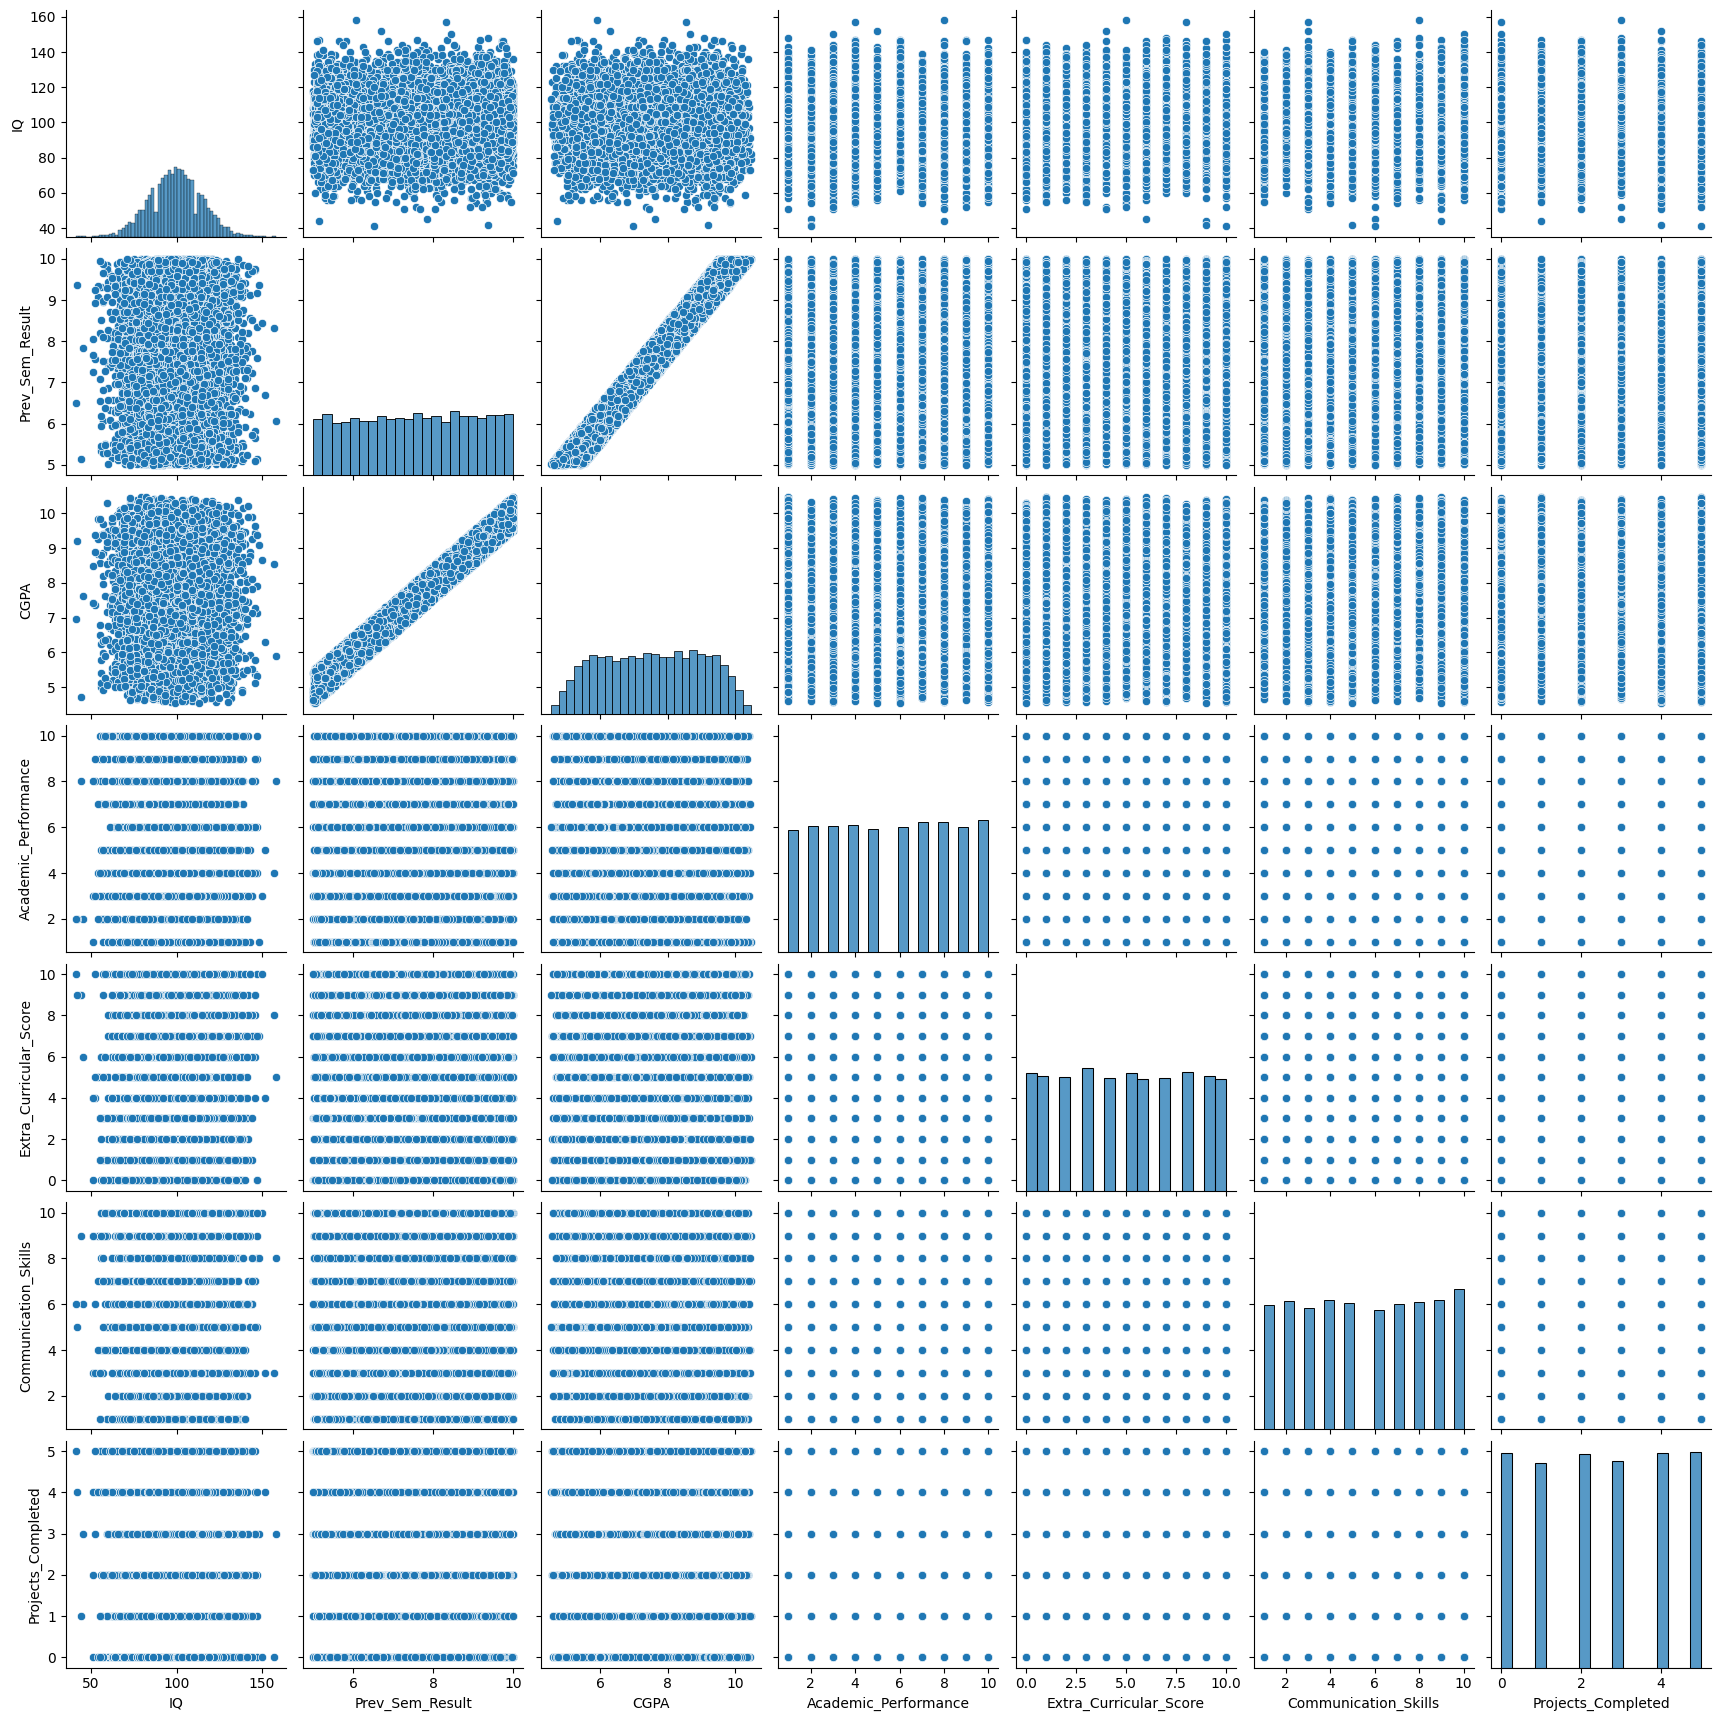

In [46]:
sns.pairplot(df[['IQ','Prev_Sem_Result','CGPA','Academic_Performance','Extra_Curricular_Score','Communication_Skills','Projects_Completed']])
plt.show()

In [47]:
encode=['Internship_Experience','Placement']

In [48]:
le=LabelEncoder()

In [49]:
for col in encode:
    df[col]=le.fit_transform(df[col])

In [50]:
print(df['Internship_Experience'],df['Placement'])

0       0
1       0
2       0
3       1
4       0
       ..
9995    0
9996    0
9997    1
9998    0
9999    0
Name: Internship_Experience, Length: 10000, dtype: int64 0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64


In [51]:
df=df.drop("College_ID",axis=1)
print(df)

       IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0     107             6.61  6.28                     8                      0   
1      97             5.52  5.37                     8                      0   
2     109             5.36  5.83                     9                      0   
3     122             5.47  5.75                     6                      1   
4      96             7.91  7.69                     7                      0   
...   ...              ...   ...                   ...                    ...   
9995  119             8.41  8.29                     4                      0   
9996   70             9.25  9.34                     7                      0   
9997   89             6.08  6.25                     3                      1   
9998  107             8.77  8.92                     3                      0   
9999  109             9.41  9.77                     8                      0   

      Extra_Curricular_Scor

In [52]:
X=df.drop("Placement",axis=1)
Y=df["Placement"]

In [53]:
feature_train,feature_test,target_train,target_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [54]:
model=DecisionTreeClassifier(criterion="gini",random_state=42)
model.fit(X,Y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
Y_pred=model.predict(feature_test)

In [56]:
print("Accuracy:",accuracy_score(target_test,Y_pred)*100)

Accuracy: 100.0


<function matplotlib.pyplot.show(close=None, block=None)>

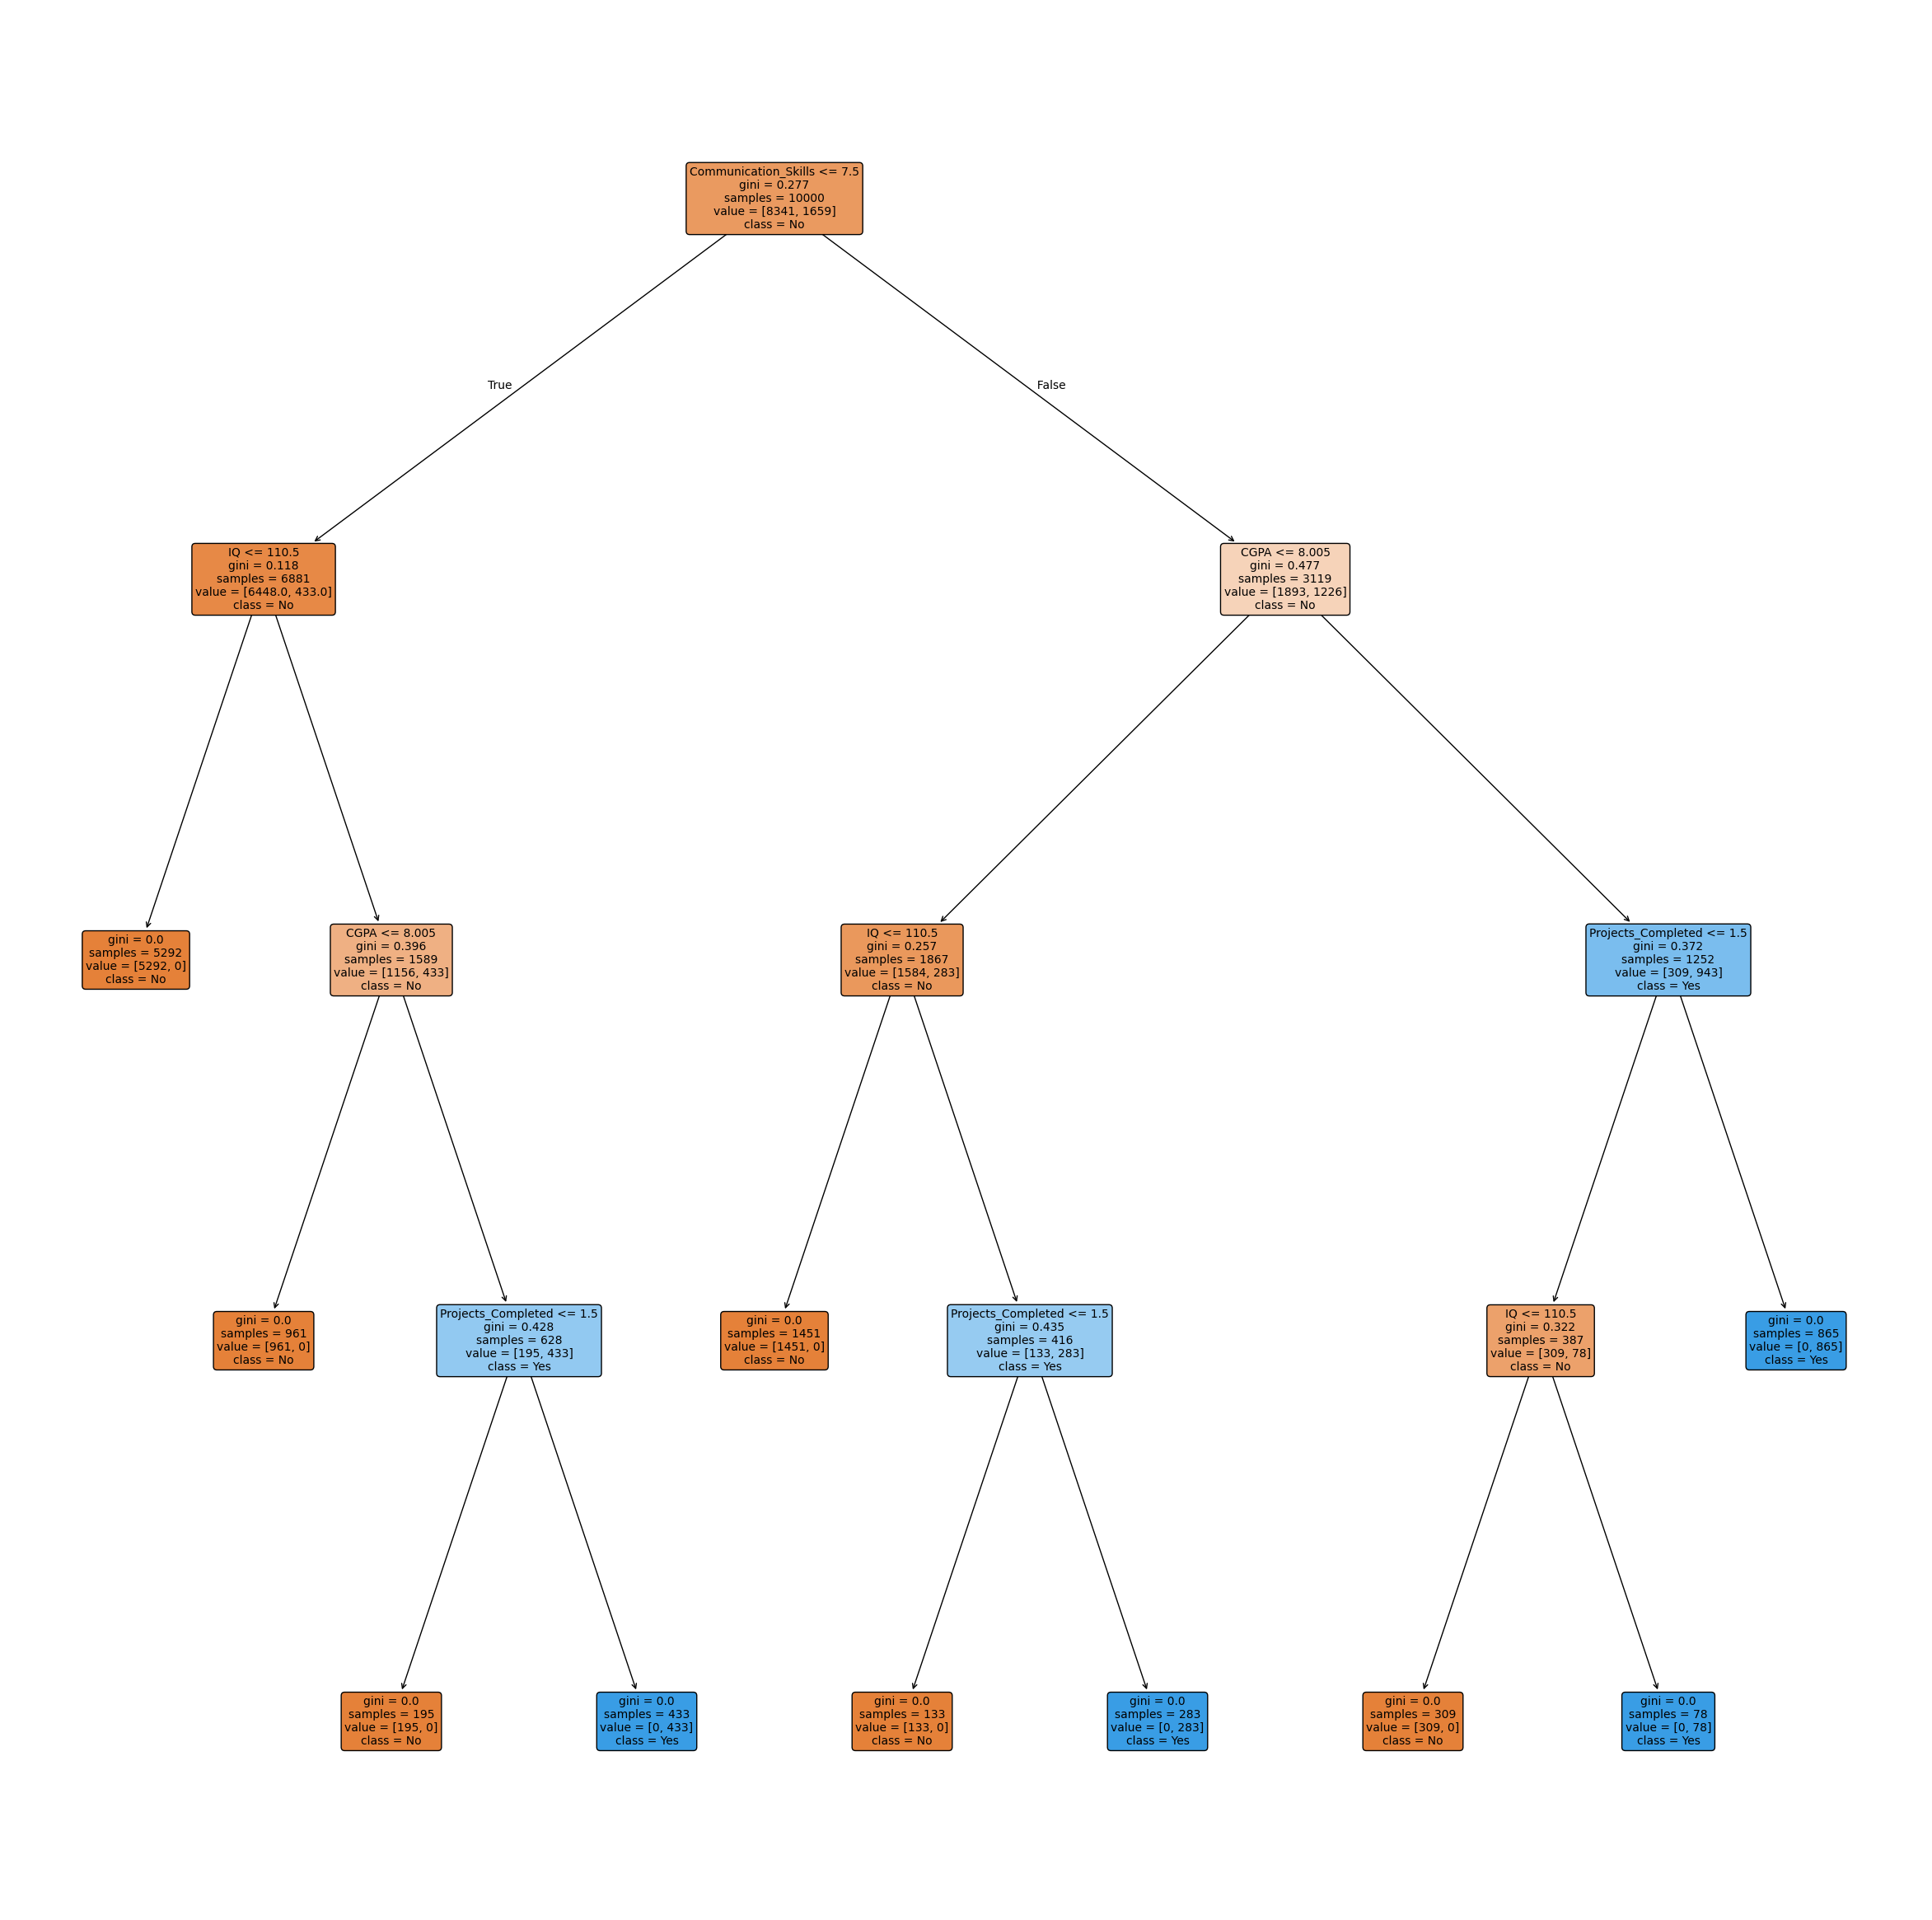

In [61]:
plt.figure(figsize=(30,30))
plot_tree(model,feature_names=X.columns,class_names=["No","Yes"],filled=True,impurity=True,rounded=True,fontsize=10)
plt.show